# Dataset Overview & Preprocessing

Documents the four study datasets and every preprocessing decision, matching the brief:

| Dataset | Task | Role in the study |
|---|---|---|
| Breast Cancer Wisconsin | binary | 30 features (>20 — high-dimensional requirement) |
| Adult Income | binary | natural ~3:1 imbalance, mixed categorical features |
| Covertype | 7-class | severe imbalance — rarest class ~0.5% (<=1% requirement) |
| MNIST 3 vs 8 | binary | 784 pixel features, >=5000 samples (brief's suggestion) |

Preprocessing (implemented in `src/utils/preprocessing.py` and `src/experiments/utils.py`):
rows with missing values dropped (Adult, <8% of rows), categoricals one-hot encoded,
features standardized with a scaler **fitted on training data only**, stratified subsets
(>=5000 in the full study) that preserve natural class ratios, and balanced class weights
as the documented treatment for Covertype's severe imbalance.

*Note: this notebook loads the reduced (`fast`) subsets so it runs in seconds; `run_all.py`
uses the full >=5000-row subsets.*

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.experiments.utils import load_datasets

FIGURES_DIR = PROJECT_ROOT / "figures" / "notebook"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

datasets = load_datasets(fast=True)
print(f"{'dataset':<14} {'shape':<14} {'classes':<8} {'minority %':<10}")
for d in datasets:
    counts = np.unique(d.y, return_counts=True)[1]
    print(f"{d.name:<14} {str(d.X.shape):<14} {counts.size:<8} "
          f"{counts.min() / d.y.size:<10.3%}")

dataset        shape          classes  minority %
breast_cancer  (569, 30)      2        37.258%   
adult          (1500, 104)    2        24.800%   
covertype      (1500, 54)     7        0.467%    
mnist_38       (1500, 784)    2        48.867%   


## Class distributions

Covertype's bars need a log scale — its rarest class (Cottonwood/Willow) is two orders of
magnitude smaller than the largest, which is exactly why plain accuracy is misleading there
and the experiments report macro F1 and use balanced class weights.

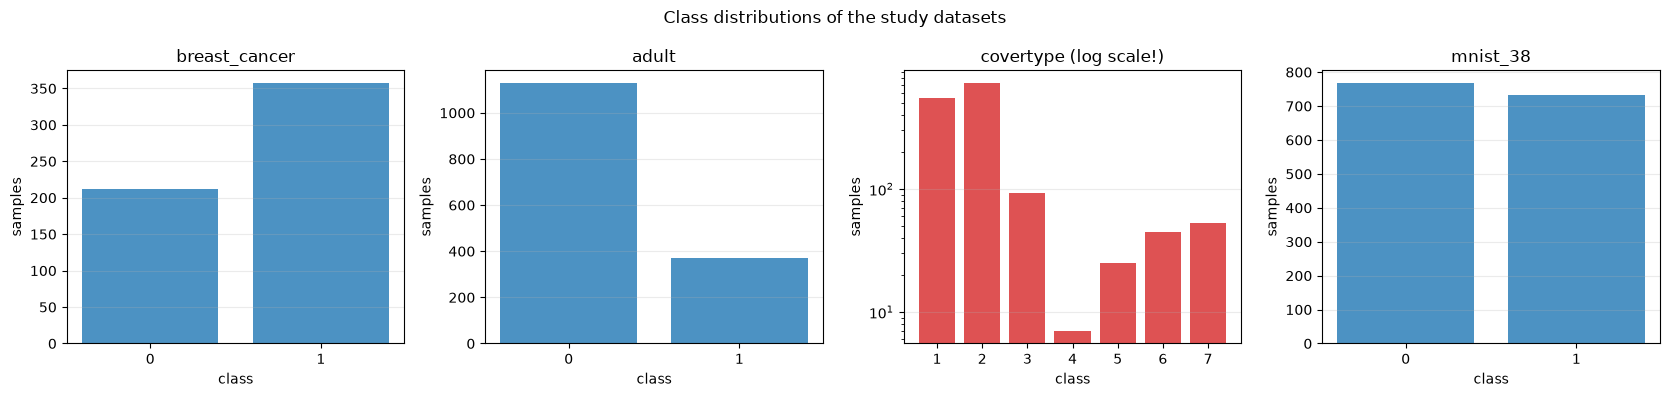

In [2]:
fig, axes = plt.subplots(1, len(datasets), figsize=(4.2 * len(datasets), 4))
for axis, d in zip(axes, datasets):
    labels, counts = np.unique(d.y, return_counts=True)
    axis.bar([str(label) for label in labels], counts,
             color="tab:red" if d.imbalanced else "tab:blue", alpha=0.8)
    if d.imbalanced:
        axis.set_yscale("log")
        axis.set_title(f"{d.name} (log scale!)")
    else:
        axis.set_title(d.name)
    axis.set(xlabel="class", ylabel="samples")
    axis.grid(alpha=0.25, axis="y")
fig.suptitle("Class distributions of the study datasets")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## A look at MNIST 3 vs 8

The 784 features are raw 28x28 pixel intensities. The pair 3/8 is deliberately confusable —
the digits share most of their stroke area, so the classifiers must rely on fine pixel
differences, a good stress test for high-dimensional splitting.

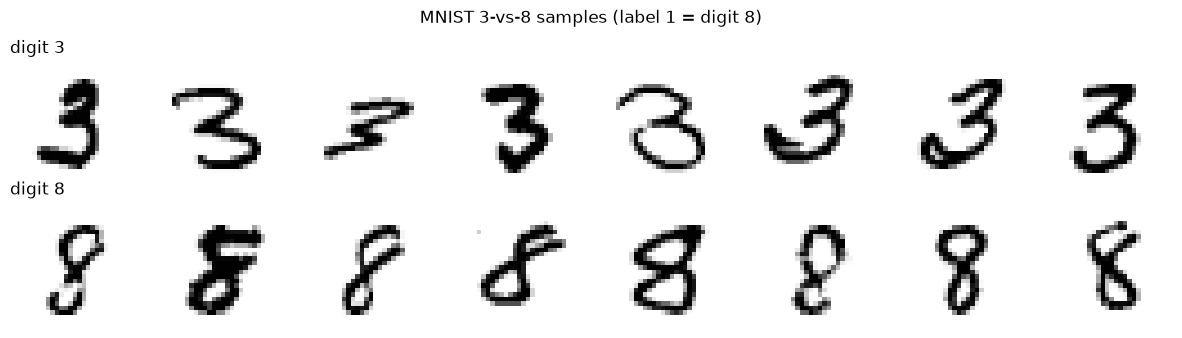

In [3]:
mnist = next(d for d in datasets if d.name == "mnist_38")
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for row, digit_class in enumerate([0, 1]):
    candidates = np.flatnonzero(mnist.y == digit_class)
    for column, index in enumerate(rng.choice(candidates, size=8, replace=False)):
        axes[row, column].imshow(mnist.X[index].reshape(28, 28), cmap="gray_r")
        axes[row, column].set_axis_off()
    axes[row, 0].set_title("digit 3" if digit_class == 0 else "digit 8", loc="left")
fig.suptitle("MNIST 3-vs-8 samples (label 1 = digit 8)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mnist_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## Adult preprocessing effect

Adult ships with 6 numeric and 8 categorical columns; after dropping rows containing
missing values and one-hot encoding the categoricals, the trees see ~104 purely continuous
0/1-or-numeric features — required because the `DecisionTree` splits on continuous values
only. The cell below shows the widths before and after encoding.

In [4]:
adult = next(d for d in datasets if d.name == "adult")
numeric_width = 6
encoded_width = adult.X.shape[1] - numeric_width
print(f"numeric columns          : {numeric_width}")
print(f"one-hot indicator columns: {encoded_width}")
print(f"total model features     : {adult.X.shape[1]}")
print(f"positive-class (>50K)    : {adult.y.mean():.1%}")
print()
print("first encoded feature names:")
for name in adult.feature_names[:10]:
    print("  ", name)

numeric columns          : 6
one-hot indicator columns: 98
total model features     : 104
positive-class (>50K)    : 24.8%

first encoded feature names:
   age
   fnlwgt
   education-num
   capital-gain
   capital-loss
   hours-per-week
   workclass=Federal-gov
   workclass=Local-gov
   workclass=Private
   workclass=Self-emp-inc
